# Comb Filter

A comb filter adds a delayed copy of a signal to itself, producing a periodic series of peaks or notches in the frequency response. The fundamental period of the comb pattern is `fs / D` Hz, where `D` is the delay in samples.

| Function | Description |
| --- | --- |
| `feedback_delay` | IIR feedback comb filter: `y[n] = x[n] + feedback · y[n−D]`. Resonant peaks grow with feedback; approaches oscillation as feedback → 1. |
| `comb_filter` | FIR feedforward comb filter: `y[n] = x[n] + gain · x[n−D]`. Alternating peaks and notches; gain > 0 gives notches at odd multiples of fs/(2D). |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import comb_filter, feedback_delay
from python.generators import generate_impulse

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Frequency responses at delay D = 441 samples (≈ 10 ms at 44 100 Hz → comb fundamental at 100 Hz).

**Left panel — IIR feedback comb, three feedback values (0.25 / 0.5 / 0.75):**
- Resonant peaks appear at 0, 100, 200, 300 … Hz (multiples of fs/D)
- Higher feedback → taller, narrower peaks; DC gain = 1/(1 − feedback)
- At feedback → 1 the filter becomes a resonator (self-oscillating comb)

**Right panel — FIR feedforward comb, three gain values (0.25 / 0.5 / 0.75):**
- Constructive interference at even multiples of fs/(2D), destructive at odd multiples
- gain > 0 creates notches at 50, 150, 250 … Hz; gain < 0 shifts the pattern by half a period
- Unlike the IIR version, magnitude is always bounded (no resonance)


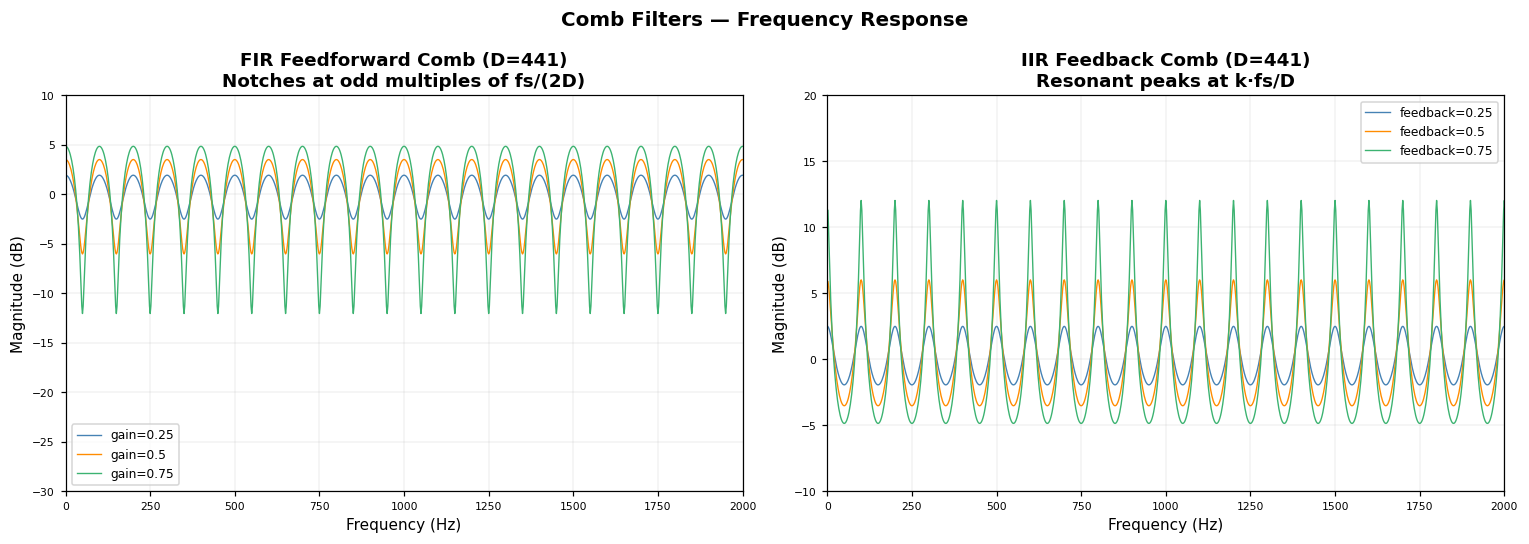

In [2]:
FS = 44100
DURATION = 0.5
DELAY_SAMPLES = 441  # ~10 ms → peaks at multiples of 100 Hz

_, impulse = generate_impulse(fs=FS, duration=DURATION)


def _freq_response(h: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spectrum = np.abs(np.fft.rfft(h))
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20.0 * np.log10(spectrum + 1e-12)
    return freqs, db


GAINS = [0.25, 0.5, 0.75]
COLORS = ["steelblue", "darkorange", "mediumseagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FIR feedforward comb
ax = axes[0]
for g, color in zip(GAINS, COLORS):
    h = comb_filter(impulse, delay_samples=DELAY_SAMPLES, gain=g)
    freqs, db = _freq_response(h)
    mask = freqs > 0
    ax.plot(freqs[mask], db[mask], label=f"gain={g}", color=color, linewidth=0.9)
ax.set_title(f"FIR Feedforward Comb (D={DELAY_SAMPLES})\nNotches at odd multiples of fs/(2D)", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(0, 2000)
ax.set_ylim(-30, 10)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.5)

# IIR feedback comb
ax = axes[1]
for g, color in zip(GAINS, COLORS):
    h = feedback_delay(impulse, delay_samples=DELAY_SAMPLES, feedback=g)
    freqs, db = _freq_response(h)
    mask = freqs > 0
    ax.plot(freqs[mask], db[mask], label=f"feedback={g}", color=color, linewidth=0.9)
ax.set_title(f"IIR Feedback Comb (D={DELAY_SAMPLES})\nResonant peaks at k·fs/D", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(0, 2000)
ax.set_ylim(-10, 20)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.5)

for ax in axes:
    ax.tick_params(labelsize=7)

fig.suptitle("Comb Filters — Frequency Response", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()